In [1]:
# Install SHAP for interpretability
!pip install shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import os
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# Paths
processed_path = '/content/drive/MyDrive/FraudDetection_project/processed_data/'
models_path = '/content/drive/MyDrive/FraudDetection_project/saved_models/'
output_path = '/content/drive/MyDrive/FraudDetection_project/outputs/'
os.makedirs(output_path, exist_ok=True)

print("Loading test data and trained classifiers...")

# Load untouched Test Sets
sparkov_test = pd.read_csv(processed_path + 'sparkov_ready_for_eval.csv')
paysim_test = pd.read_csv(processed_path + 'paysim_ready_for_eval.csv')

# Load Models
xgb_sparkov = joblib.load(models_path + 'xgb_sparkov_model.joblib')
xgb_paysim = joblib.load(models_path + 'xgb_paysim_model.joblib')

print("Assets loaded successfully!")

Mounted at /content/drive
Loading test data and trained classifiers...
Assets loaded successfully!


--- SPARKOV CLASSIFIER EVALUATION ---

Sparkov Classification Report:
                precision    recall  f1-score   support

Legitimate (0)       1.00      1.00      1.00    553574
     Fraud (1)       0.48      0.87      0.62      2145

      accuracy                           1.00    555719
     macro avg       0.74      0.94      0.81    555719
  weighted avg       1.00      1.00      1.00    555719



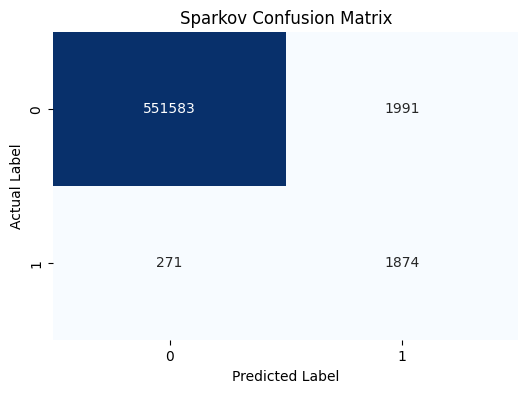

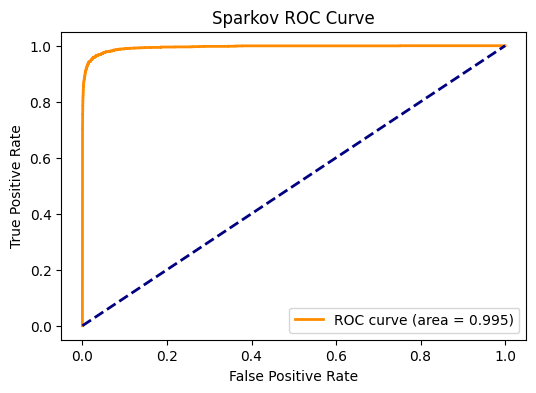

In [2]:
print("--- SPARKOV CLASSIFIER EVALUATION ---")

# Separate features and target
X_test_sp = sparkov_test.drop(columns=['is_fraud'])
y_test_sp = sparkov_test['is_fraud']

# Get predictions and probabilities
y_pred_sp = xgb_sparkov.predict(X_test_sp)
y_prob_sp = xgb_sparkov.predict_proba(X_test_sp)[:, 1]

# 1. Classification Report
print("\nSparkov Classification Report:")
print(classification_report(y_test_sp, y_pred_sp, target_names=['Legitimate (0)', 'Fraud (1)']))

# 2. Confusion Matrix
plt.figure(figsize=(6, 4))
cm_sp = confusion_matrix(y_test_sp, y_pred_sp)
sns.heatmap(cm_sp, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Sparkov Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.savefig(output_path + 'sparkov_confusion_matrix.png', bbox_inches='tight')
plt.show()

# 3. ROC Curve
fpr, tpr, _ = roc_curve(y_test_sp, y_prob_sp)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('Sparkov ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.savefig(output_path + 'sparkov_roc_curve.png', bbox_inches='tight')
plt.show()

--- PAYSIM CLASSIFIER EVALUATION ---

PaySim Classification Report:
                precision    recall  f1-score   support

Legitimate (0)       1.00      0.96      0.98   1270877
     Fraud (1)       0.03      1.00      0.06      1647

      accuracy                           0.96   1272524
     macro avg       0.52      0.98      0.52   1272524
  weighted avg       1.00      0.96      0.98   1272524



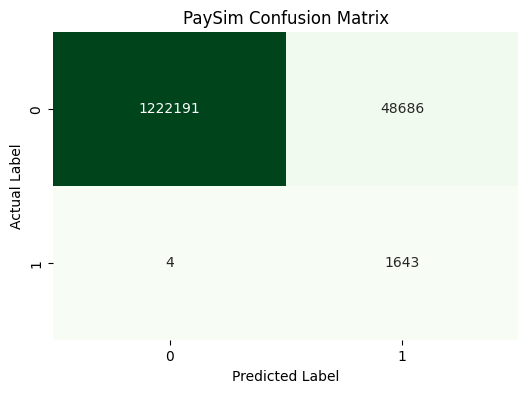

In [3]:
print("--- PAYSIM CLASSIFIER EVALUATION ---")

X_test_ps = paysim_test.drop(columns=['isFraud'])
y_test_ps = paysim_test['isFraud']

y_pred_ps = xgb_paysim.predict(X_test_ps)
y_prob_ps = xgb_paysim.predict_proba(X_test_ps)[:, 1]

print("\nPaySim Classification Report:")
print(classification_report(y_test_ps, y_pred_ps, target_names=['Legitimate (0)', 'Fraud (1)']))

plt.figure(figsize=(6, 4))
cm_ps = confusion_matrix(y_test_ps, y_pred_ps)
sns.heatmap(cm_ps, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('PaySim Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.savefig(output_path + 'paysim_confusion_matrix.png', bbox_inches='tight')
plt.show()

--- MODEL INTERPRETABILITY (SHAP) ---
Calculating SHAP values for Sparkov... (Using a sample of 2000 rows for speed)

Generating SHAP Summary Plot...


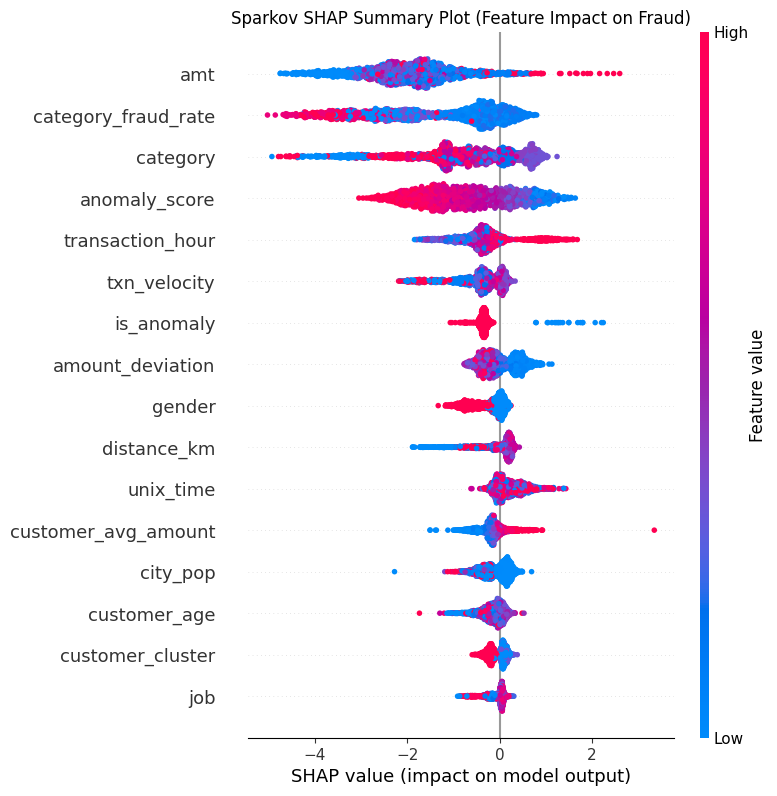


Day 8 Deliverables successfully completed and saved!


In [4]:
print("--- MODEL INTERPRETABILITY (SHAP) ---")
print("Calculating SHAP values for Sparkov... (Using a sample of 2000 rows for speed)")

# Take a random sample to prevent Colab RAM crashes
X_test_sample = X_test_sp.sample(n=2000, random_state=42)

# Create the SHAP Explainer
explainer = shap.TreeExplainer(xgb_sparkov)
shap_values = explainer.shap_values(X_test_sample)

# 1. SHAP Summary Plot (Global Feature Importance)
print("\nGenerating SHAP Summary Plot...")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.title("Sparkov SHAP Summary Plot (Feature Impact on Fraud)")
plt.savefig(output_path + 'sparkov_shap_summary.png', bbox_inches='tight')
plt.show()

print("\nDay 8 Deliverables successfully completed and saved!")

Mounted at /content/drive

--- TUNING PAYSIM (Fixing the False Positives) ---
Loading PaySim datasets...
Training the 'Calmer' PaySim Classifier... (This will take a few minutes)
Evaluating Tuned Model...

NEW PaySim Classification Report (Tuned):
                precision    recall  f1-score   support

Legitimate (0)       1.00      0.99      0.99   1270877
     Fraud (1)       0.09      0.83      0.16      1647

      accuracy                           0.99   1272524
     macro avg       0.55      0.91      0.58   1272524
  weighted avg       1.00      0.99      0.99   1272524



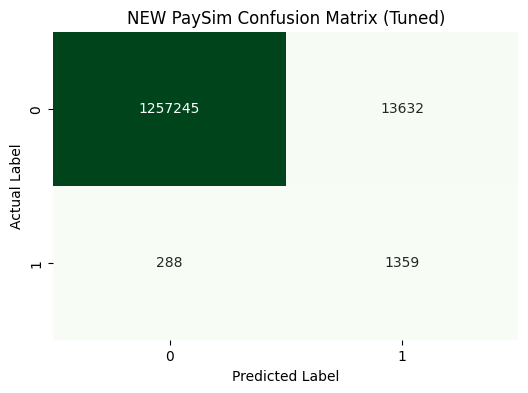


Success! Overwrote the overly paranoid model with the tuned production model.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# --- MOUNT DRIVE FIRST ---
from google.colab import drive
drive.mount('/content/drive')

# Paths
processed_path = '/content/drive/MyDrive/FraudDetection_project/processed_data/'
models_path = '/content/drive/MyDrive/FraudDetection_project/saved_models/'
output_path = '/content/drive/MyDrive/FraudDetection_project/outputs/'

print("\n--- TUNING PAYSIM (Fixing the False Positives) ---")

# 1. Load the training AND test data fresh from Drive
print("Loading PaySim datasets...")
paysim_train = pd.read_csv(processed_path + 'paysim_train_processed.csv')
paysim_test = pd.read_csv(processed_path + 'paysim_ready_for_eval.csv')

X_train_ps = paysim_train.drop(columns=['isFraud'])
y_train_ps = paysim_train['isFraud']

X_test_ps = paysim_test.drop(columns=['isFraud'])
y_test_ps = paysim_test['isFraud']

# 2. Retrain WITHOUT scale_pos_weight
print("Training the 'Calmer' PaySim Classifier... (This will take a few minutes)")
xgb_paysim_tuned = XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.1,
    # scale_pos_weight=10,  <-- THIS IS THE CULPRIT WE REMOVED
    random_state=42,
    n_jobs=-1
)
xgb_paysim_tuned.fit(X_train_ps, y_train_ps)

# 3. Re-Evaluate
print("Evaluating Tuned Model...")
y_pred_ps_tuned = xgb_paysim_tuned.predict(X_test_ps)

print("\nNEW PaySim Classification Report (Tuned):")
print(classification_report(y_test_ps, y_pred_ps_tuned, target_names=['Legitimate (0)', 'Fraud (1)']))

# 4. Confusion Matrix
plt.figure(figsize=(6, 4))
cm_ps_tuned = confusion_matrix(y_test_ps, y_pred_ps_tuned)
sns.heatmap(cm_ps_tuned, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('NEW PaySim Confusion Matrix (Tuned)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.savefig(output_path + 'paysim_confusion_matrix_tuned.png', bbox_inches='tight')
plt.show()

# 5. Overwrite the Vault
joblib.dump(xgb_paysim_tuned, models_path + 'xgb_paysim_model.joblib')
print("\nSuccess! Overwrote the overly paranoid model with the tuned production model.")